# Reproducing the main Humanoid numbers

This notebook reads the saved N=20 Humanoid summary table and replots the two headline quantities: fall-AUC reduction and return-AUC gain.  Lower fall AUC is better, so the notebook flips the sign and plots a positive 'fall reduction'.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_submission_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / 'derived_tables').exists() and (p / 'myst_submission').exists():
            return p
        if (p / 'myst.yml').exists() and (p.parent / 'derived_tables').exists():
            return p.parent
        if (p / 'index.md').exists() and (p.parent / 'derived_tables').exists():
            return p.parent
    return start

ROOT = find_submission_root()
summary_path = ROOT / 'derived_tables' / 'humanoid20_key_results.csv'
if not summary_path.exists():
    raise FileNotFoundError(
        f'Missing saved results table: {summary_path}. ' +
        'Place humanoid20_key_results.csv in derived_tables/ before running this notebook.'
    )
df = pd.read_csv(summary_path)
df.head()

,sweep_type,metric,comparison,n_seeds,mean,sem,ci_low,ci_high
0,push,fall,consolidated_minus_baseline,20,-0.310660,0.090599,-0.487848,-0.145903
1,sensor,fall,consolidated_minus_baseline,20,-0.406250,0.053362,-0.509375,-0.306250
2,slip,fall,consolidated_minus_baseline,20,-0.316292,0.090367,-0.495569,-0.148999
3,push,recovery,consolidated_minus_baseline,20,-24.601825,10.963316,-47.528723,-6.518862
4,sensor,recovery,consolidated_minus_baseline,20,-3.259375,2.111422,-7.901046,-0.163837


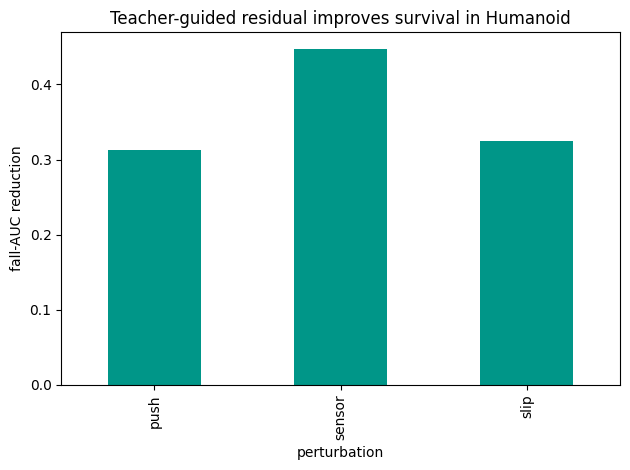

In [2]:
plot_df = df[(df.comparison == 'imitation_on_minus_off') & (df.metric == 'fall')].copy()
plot_df['fall_reduction'] = -plot_df['mean']
ax = plot_df.plot.bar(x='sweep_type', y='fall_reduction', legend=False, color='#009688')
ax.set_ylabel('fall-AUC reduction')
ax.set_xlabel('perturbation')
ax.set_title('Teacher-guided residual improves survival in Humanoid')
plt.tight_layout()

In [3]:
for _, row in plot_df.iterrows():
    print(f"{row.sweep_type}: fall delta={row['mean']:.3f}, 95% CI=[{row.ci_low:.3f}, {row.ci_high:.3f}], n={int(row.n_seeds)}")

push: fall delta=-0.313, 95% CI=[-0.491, -0.147], n=20
sensor: fall delta=-0.447, 95% CI=[-0.553, -0.338], n=20
slip: fall delta=-0.325, 95% CI=[-0.511, -0.155], n=20
